In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize

plt.style.use('seaborn-v0_8')
print(" Libraries loaded!")

 Libraries loaded!


In [2]:
df = pd.read_csv('../data/processed/all_stocks_featured.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

print(f" Data loaded: {df.shape}")
print(f"Stocks: {df['Symbol'].nunique()}")

 Data loaded: (117464, 37)
Stocks: 49


In [3]:
# Pivot close prices
close_prices = df.pivot_table(
    index='Date', columns='Symbol', values='Close'
)

# Drop columns with too many NaN
close_prices = close_prices.dropna(axis=1, thresh=int(len(close_prices)*0.8))
close_prices = close_prices.fillna(method='ffill')

# Daily returns
returns = close_prices.pct_change().dropna()

print(f"Stocks available: {len(returns.columns)}")
print(f"Date range: {returns.index[0]} to {returns.index[-1]}")
print(f"Trading days: {len(returns)}")

# Annual stats
annual_returns = returns.mean() * 252
annual_vol     = returns.std() * np.sqrt(252)
sharpe_ratios  = annual_returns / annual_vol

print("\nTop 5 by Annual Return:")
print(annual_returns.sort_values(ascending=False).head())

Stocks available: 47
Date range: 2012-11-02 00:00:00 to 2021-04-30 00:00:00
Trading days: 2099

Top 5 by Annual Return:
Symbol
BAJFINANCE    0.415745
BAJAJFINSV    0.365888
BRITANNIA     0.297318
ADANIPORTS    0.285256
SHREECEM      0.270998
dtype: float64


In [4]:
def portfolio_performance(weights, returns, risk_free=0.06):
    weights     = np.array(weights)
    port_return = np.sum(returns.mean() * weights) * 252
    port_vol    = np.sqrt(
        np.dot(weights.T, np.dot(returns.cov() * 252, weights))
    )
    sharpe = (port_return - risk_free) / port_vol
    return port_return, port_vol, sharpe

def optimize_portfolio(returns, objective='sharpe', 
                       max_weight=0.30, min_weight=0.01):
    n = len(returns.columns)
    
    # Constraints
    constraints = [{'type': 'eq', 
                    'fun': lambda x: np.sum(x) - 1}]
    
    # Bounds
    if objective == 'conservative':
        bounds = tuple((min_weight, 0.15) for _ in range(n))
    elif objective == 'aggressive':
        bounds = tuple((min_weight, max_weight) for _ in range(n))
    else:
        bounds = tuple((min_weight, 0.20) for _ in range(n))
    
    # Initial weights
    w0 = np.array([1/n] * n)
    
    if objective == 'sharpe':
        # Maximize Sharpe
        def neg_sharpe(w):
            r, v, s = portfolio_performance(w, returns)
            return -s
        result = minimize(neg_sharpe, w0, method='SLSQP',
                         bounds=bounds, constraints=constraints)
    
    elif objective == 'conservative':
        # Minimize volatility
        def min_vol(w):
            _, v, _ = portfolio_performance(w, returns)
            return v
        result = minimize(min_vol, w0, method='SLSQP',
                         bounds=bounds, constraints=constraints)
    
    elif objective == 'aggressive':
        # Maximize return
        def neg_return(w):
            r, _, _ = portfolio_performance(w, returns)
            return -r
        result = minimize(neg_return, w0, method='SLSQP',
                         bounds=bounds, constraints=constraints)
    
    return result.x

print(" Portfolio optimization engine ready!")

 Portfolio optimization engine ready!


In [5]:
# Select top 20 liquid stocks for portfolio
selected_stocks = annual_returns.sort_values(
    ascending=False).head(20).index.tolist()
returns_selected = returns[selected_stocks]

print("Building 3 investor portfolios...")
print(f"Universe: {len(selected_stocks)} stocks\n")

# Optimize all 3
w_conservative = optimize_portfolio(
    returns_selected, objective='conservative')
w_balanced     = optimize_portfolio(
    returns_selected, objective='sharpe')
w_aggressive   = optimize_portfolio(
    returns_selected, objective='aggressive')

# Performance
r_con, v_con, s_con = portfolio_performance(
    w_conservative, returns_selected)
r_bal, v_bal, s_bal = portfolio_performance(
    w_balanced,     returns_selected)
r_agg, v_agg, s_agg = portfolio_performance(
    w_aggressive,   returns_selected)

print("=" * 60)
print(f"  {'Profile':<20} {'Return':>10} {'Risk':>10} {'Sharpe':>10}")
print("-" * 60)
print(f"  {'Conservative':<20} {r_con*100:>9.1f}% {v_con*100:>9.1f}% {s_con:>10.2f}")
print(f"  {'Balanced':<20} {r_bal*100:>9.1f}% {v_bal*100:>9.1f}% {s_bal:>10.2f}")
print(f"  {'Aggressive':<20} {r_agg*100:>9.1f}% {v_agg*100:>9.1f}% {s_agg:>10.2f}")
print("=" * 60)

Building 3 investor portfolios...
Universe: 20 stocks

  Profile                  Return       Risk     Sharpe
------------------------------------------------------------
  Conservative              20.2%      15.6%       0.91
  Balanced                  28.3%      19.3%       1.15
  Aggressive                33.8%      26.6%       1.05


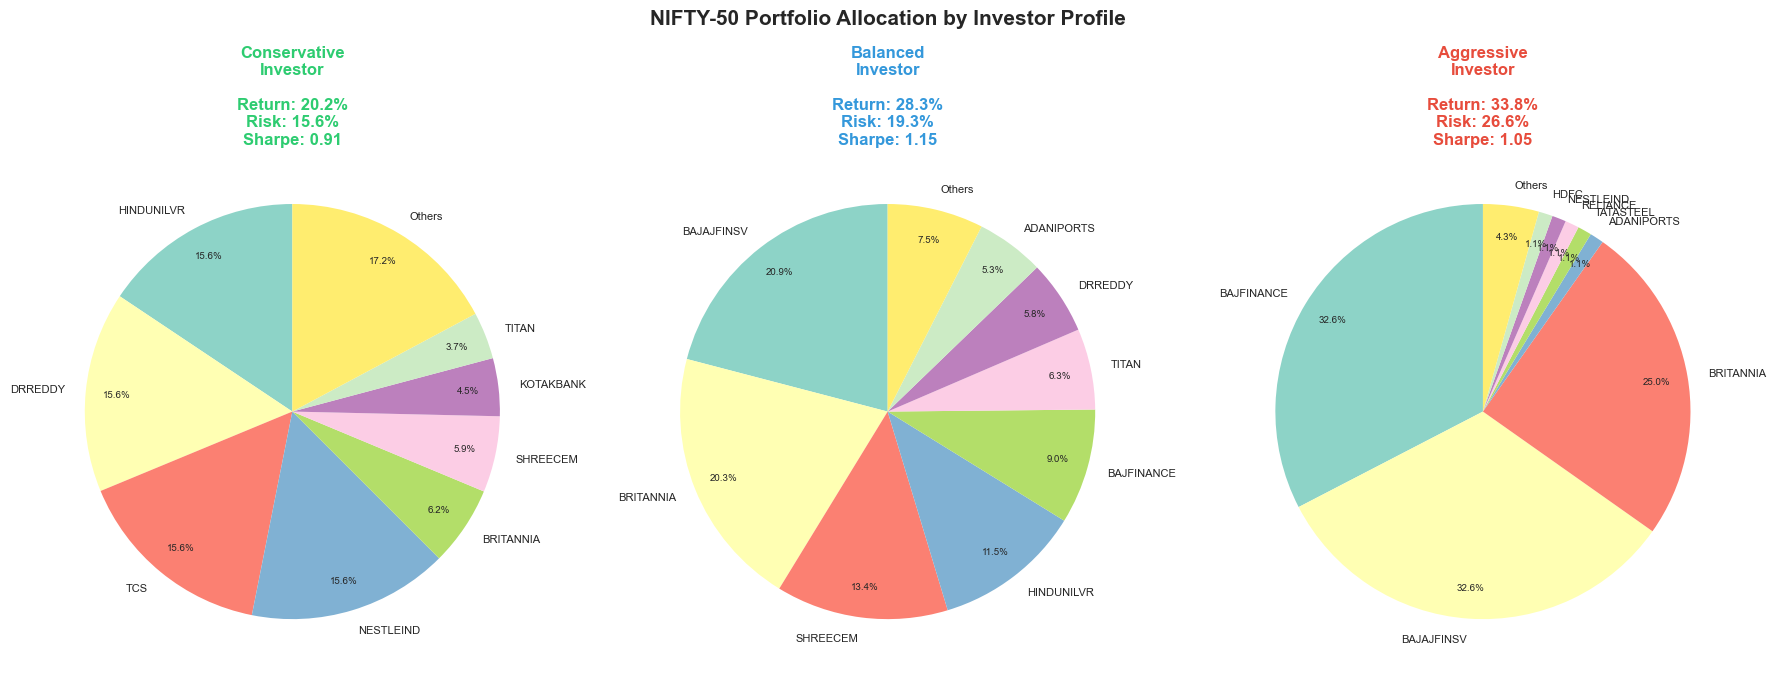

 Portfolio allocation chart saved!


In [6]:
def get_top_holdings(weights, stocks, n=8):
    w_df = pd.Series(weights, index=stocks)
    w_df = w_df[w_df > 0.01].sort_values(ascending=False)
    top  = w_df.head(n)
    others = pd.Series({'Others': w_df.iloc[n:].sum()})
    return pd.concat([top, others])

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

profiles = [
    ('Conservative\nInvestor', w_conservative, 
     '#2ECC71', f'Return: {r_con*100:.1f}%\nRisk: {v_con*100:.1f}%\nSharpe: {s_con:.2f}'),
    ('Balanced\nInvestor',     w_balanced,
     '#3498DB', f'Return: {r_bal*100:.1f}%\nRisk: {v_bal*100:.1f}%\nSharpe: {s_bal:.2f}'),
    ('Aggressive\nInvestor',   w_aggressive,
     '#E74C3C', f'Return: {r_agg*100:.1f}%\nRisk: {v_agg*100:.1f}%\nSharpe: {s_agg:.2f}'),
]

for ax, (title, weights, color, stats) in zip(axes, profiles):
    holdings = get_top_holdings(weights, selected_stocks)
    colors   = plt.cm.Set3(np.linspace(0, 1, len(holdings)))
    
    wedges, texts, autotexts = ax.pie(
        holdings.values,
        labels=holdings.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        pctdistance=0.85
    )
    
    for text in texts:
        text.set_fontsize(8)
    for autotext in autotexts:
        autotext.set_fontsize(7)
    
    ax.set_title(f'{title}\n\n{stats}', 
                 fontsize=12, fontweight='bold', color=color)

plt.suptitle('NIFTY-50 Portfolio Allocation by Investor Profile',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/portfolio_allocation.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(" Portfolio allocation chart saved!")

Generating Efficient Frontier (takes ~1 min)...


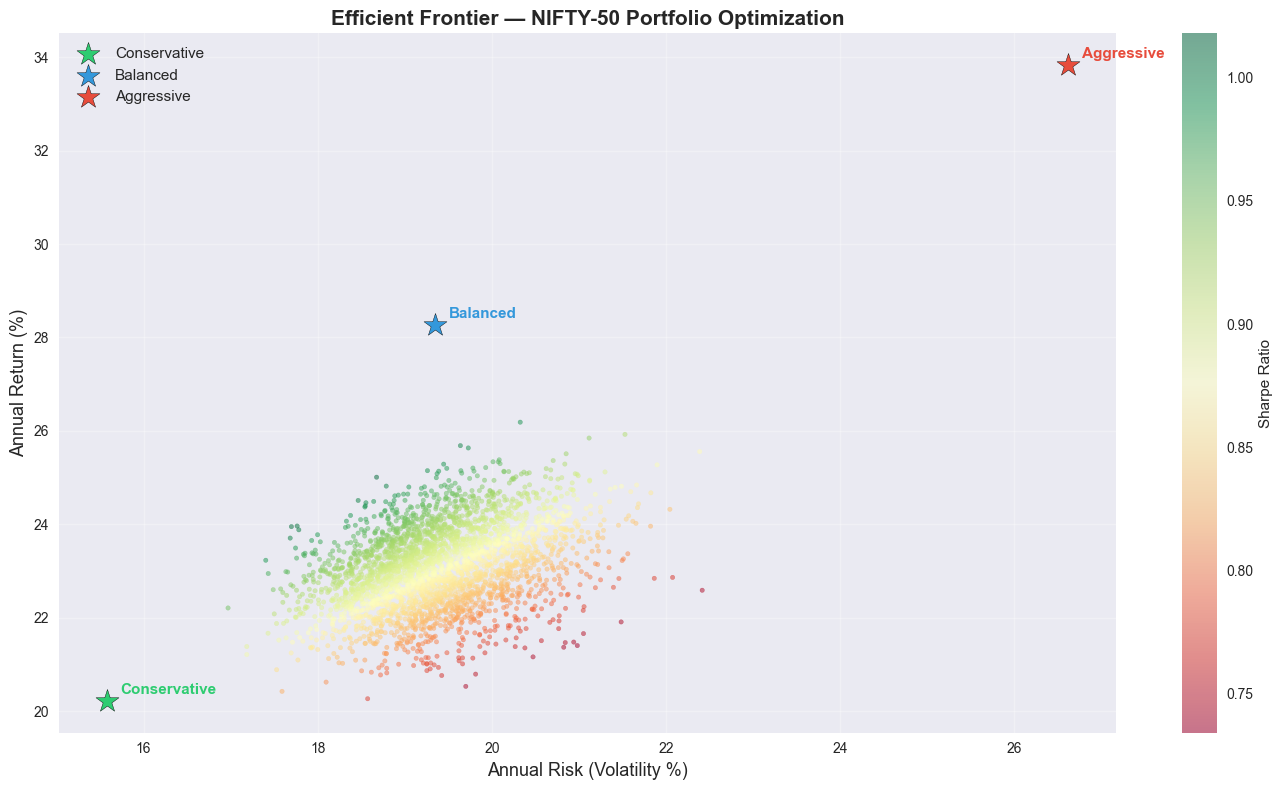

 Efficient Frontier saved!


In [7]:
print("Generating Efficient Frontier (takes ~1 min)...")

# Monte Carlo simulation
n_portfolios = 3000
results      = np.zeros((3, n_portfolios))
weights_list = []

for i in range(n_portfolios):
    w = np.random.random(len(selected_stocks))
    w = w / np.sum(w)
    r, v, s      = portfolio_performance(w, returns_selected)
    results[0, i] = v * 100   # Risk
    results[1, i] = r * 100   # Return
    results[2, i] = s          # Sharpe

plt.figure(figsize=(14, 8))

# Plot random portfolios
scatter = plt.scatter(
    results[0], results[1],
    c=results[2], cmap='RdYlGn',
    alpha=0.5, s=10
)
plt.colorbar(scatter, label='Sharpe Ratio')

# Plot our 3 portfolios
portfolios = [
    ('Conservative', v_con*100, r_con*100, '#2ECC71', '*', 300),
    ('Balanced',     v_bal*100, r_bal*100, '#3498DB', '*', 300),
    ('Aggressive',   v_agg*100, r_agg*100, '#E74C3C', '*', 300),
]

for name, vol, ret, color, marker, size in portfolios:
    plt.scatter(vol, ret, c=color, marker=marker,
                s=size, label=name, zorder=5, edgecolors='black')
    plt.annotate(name, (vol, ret),
                 textcoords='offset points',
                 xytext=(10, 5), fontsize=11,
                 fontweight='bold', color=color)

plt.xlabel('Annual Risk (Volatility %)', fontsize=13)
plt.ylabel('Annual Return (%)',           fontsize=13)
plt.title('Efficient Frontier — NIFTY-50 Portfolio Optimization',
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/efficient_frontier.png', dpi=150)
plt.show()
print(" Efficient Frontier saved!")

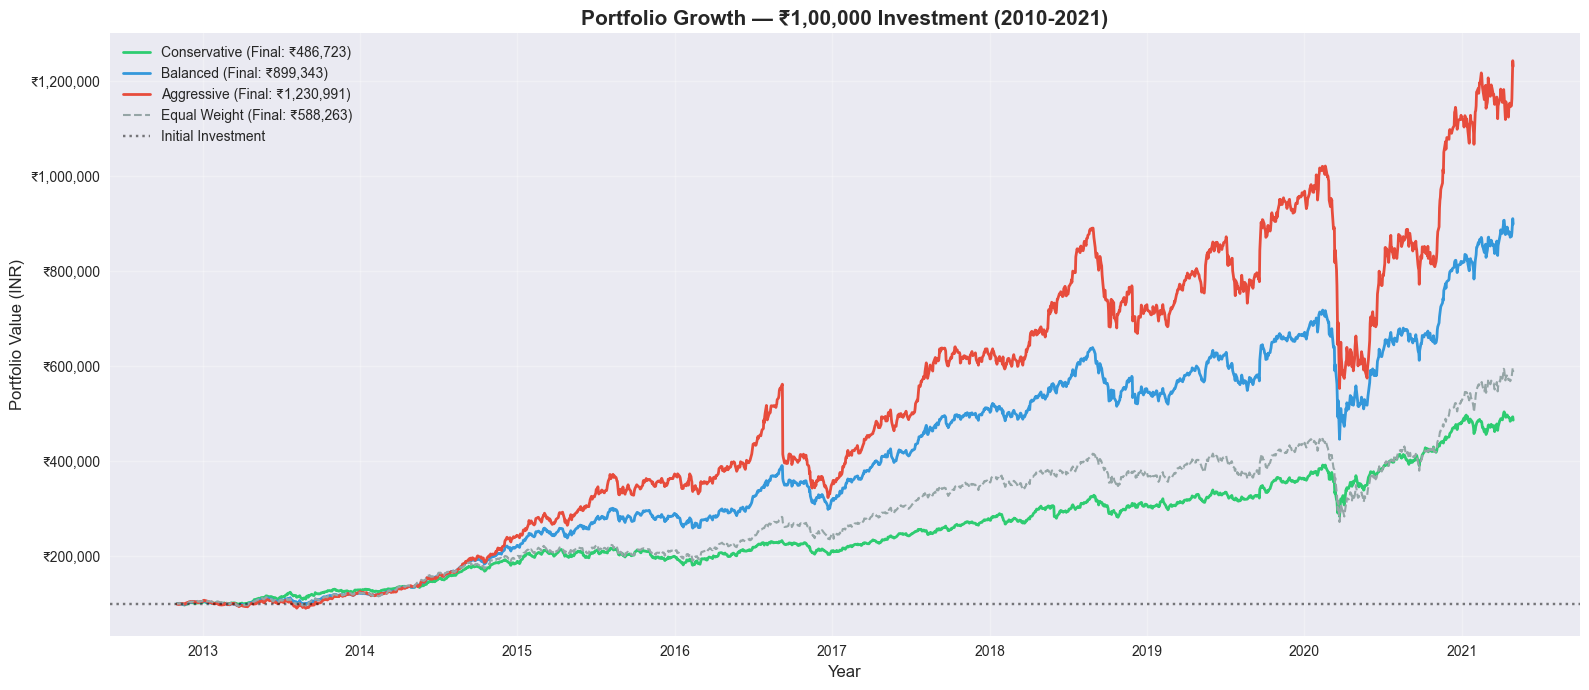

In [8]:
# Simulate ₹1,00,000 investment
investment = 100000

fig, ax = plt.subplots(figsize=(16, 7))

colors   = ['#2ECC71', '#3498DB', '#E74C3C', '#95A5A6']
profiles = [
    ('Conservative', w_conservative),
    ('Balanced',     w_balanced),
    ('Aggressive',   w_aggressive),
]

for (name, weights), color in zip(profiles, colors):
    port_returns = returns_selected.dot(weights)
    cumulative   = (1 + port_returns).cumprod()
    portfolio_value = cumulative * investment
    
    ax.plot(returns_selected.index,
            portfolio_value,
            label=f'{name} (Final: ₹{portfolio_value.iloc[-1]:,.0f})',
            color=color, linewidth=2)

# Equal weight benchmark
eq_weights   = np.array([1/len(selected_stocks)] * len(selected_stocks))
eq_returns   = returns_selected.dot(eq_weights)
eq_cumulative = (1 + eq_returns).cumprod() * investment
ax.plot(returns_selected.index, eq_cumulative,
        label=f'Equal Weight (Final: ₹{eq_cumulative.iloc[-1]:,.0f})',
        color='#95A5A6', linewidth=1.5, linestyle='--')

ax.axhline(y=investment, color='black',
           linestyle=':', alpha=0.5, label='Initial Investment')
ax.set_title('Portfolio Growth — ₹1,00,000 Investment (2010-2021)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Portfolio Value (INR)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Format y-axis
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('../data/processed/portfolio_growth.png', dpi=150)
plt.show()

In [9]:
# Save weights
portfolio_df = pd.DataFrame({
    'Stock':         selected_stocks,
    'Conservative':  np.round(w_conservative * 100, 2),
    'Balanced':      np.round(w_balanced     * 100, 2),
    'Aggressive':    np.round(w_aggressive   * 100, 2)
})
portfolio_df = portfolio_df.sort_values(
    'Balanced', ascending=False)
portfolio_df.to_csv(
    '../data/processed/portfolio_weights.csv', index=False)

print("Portfolio Weights (%):")
print(portfolio_df[portfolio_df['Balanced'] > 1].to_string(index=False))
print("\n  Portfolio data saved!")
print("\n  Portfolio Module Complete!")

Portfolio Weights (%):
     Stock  Conservative  Balanced  Aggressive
BAJAJFINSV          1.00     19.46        30.0
 BRITANNIA          5.96     18.91        23.0
  SHREECEM          5.69     12.48         1.0
HINDUNILVR         15.00     10.71         1.0
BAJFINANCE          1.00      8.34        30.0
     TITAN          3.51      5.86         1.0
   DRREDDY         15.00      5.35         1.0
ADANIPORTS          1.00      4.94         1.0
       TCS         15.00      2.95         1.0

  Portfolio data saved!

  Portfolio Module Complete!
